In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Konfigurasi path berkas input dan folder output proyekmu
INPUT_PATH = '../outputs/sentiment_clean.csv'
OUTPUT_DIR = '../outputs/'

# Memastikan folder outputs sudah tersedia sebelum menyimpan gambar
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(INPUT_PATH):
    print(f"[EROR] Berkas tidak ditemukan di: {INPUT_PATH}")
    print("Pastikan kamu sudah menjalankan tahap pembersihan sentimen sebelumnya.")
else:
    print("Memuat data sentimen bersih...")
    df_sentiment = pd.read_csv(INPUT_PATH)

    # 2. Mengekstraksi komponen tahun dari kolom timestamp bawaan berkas
    df_sentiment['year'] = pd.to_datetime(df_sentiment['timestamp']).dt.year

    # 3. Mendapatkan daftar tahun secara unik dan berurutan (2016-2025)
    unique_years = sorted(df_sentiment['year'].unique())

    print(f"Daftar tahun yang ditemukan: {unique_years}")
    print(f"Memulai pembuatan 10 visualisasi terpisah ke folder: {OUTPUT_DIR}")

    # 4. ITERASI UTAMA: Membuat dan menyimpan grafik secara terpisah untuk setiap tahun
    for target_year in unique_years:
        
        # Saring data khusus untuk tahun yang sedang berjalan dalam looping
        df_year = df_sentiment[df_sentiment['year'] == target_year]
        
        # Hitung frekuensi masing-masing sentimen pada tahun tersebut
        sentiment_counts = df_year['sentiment'].value_counts()
        
        # Mengunci urutan label dan mencocokkan dengan permintaan warna baru kamu
        # Urutan: negative (Merah), neutral (Oranye), positive (Biru)
        labels = ['negative', 'neutral', 'positive']
        counts = [sentiment_counts.get(label, 0) for label in labels]
        colors = ['#d32f2f', '#f57c00', '#1976d2']  # Merah, Oranye, Biru (Muted Academic)
        
        # Jika tidak ada data sama sekali di tahun tersebut, lewati proses plotting
        if sum(counts) == 0:
            continue

        # Inisialisasi kanvas baru untuk setiap tahun
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # Membuat Diagram Batang (Bar Chart) individual per tahun dengan warna baru
        bars = ax.bar(
            ['Negatif', 'Netral', 'Positif'], 
            counts, 
            color=colors,
            width=0.6
        )
        
        # Menambahkan angka jumlah tweet tepat di atas setiap batang diagram
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # Jarak teks 3 poin di atas batas tiang batang
                textcoords="offset points",
                ha='center', 
                va='bottom', 
                fontsize=9,
                fontweight='bold'
            )

        # Mengatur judul spesifik sesuai tahun berjalan beserta label sumbu
        ax.set_title(f"Distribusi Sentimen Opini Publik - Tahun {target_year}", fontsize=11, fontweight='bold', pad=15)
        ax.set_xlabel("Kategori Sentimen", fontsize=9, labelpad=8)
        ax.set_ylabel("Jumlah Tweet", fontsize=9, labelpad=8)
        
        # Mengatur batas visual agar aman dan tidak ada teks yang terpotong
        plt.tight_layout()
        
        # 5. MENYIMPAN GAMBAR PADA FOLDER OUTPUTS
        # Menggabungkan OUTPUT_DIR ('../outputs/') dengan nama berkas dinamis secara aman
        filename = f'sentimen_tahun_{target_year}.png'
        full_output_path = os.path.join(OUTPUT_DIR, filename)
        
        plt.savefig(full_output_path, dpi=300)
        plt.close()  # Mengosongkan kanvas dari memori komputer
        
        print(f" -> Berhasil menyimpan: {full_output_path} (Total data: {sum(counts)})")

    print("\n[SUKSES TOTAL] 10 file gambar sentimen tahunan bermutu tinggi berhasil tersimpan di folder outputs!")

Memuat data sentimen bersih...
Daftar tahun yang ditemukan: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Memulai pembuatan 10 visualisasi terpisah ke folder: ../outputs/
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2016.png (Total data: 4164)
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2017.png (Total data: 4371)
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2018.png (Total data: 2256)
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2019.png (Total data: 369)
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2020.png (Total data: 489)
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2021.png (Total data: 602)
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2022.png (Total data: 30)
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2023.png (Total data: 72)
 -> Berhasil menyimpan: ../outputs/sentimen_tahun_2024.png (Total data: 623)
 -> Berhasil menyimp

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29568\1242744909.py:203: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


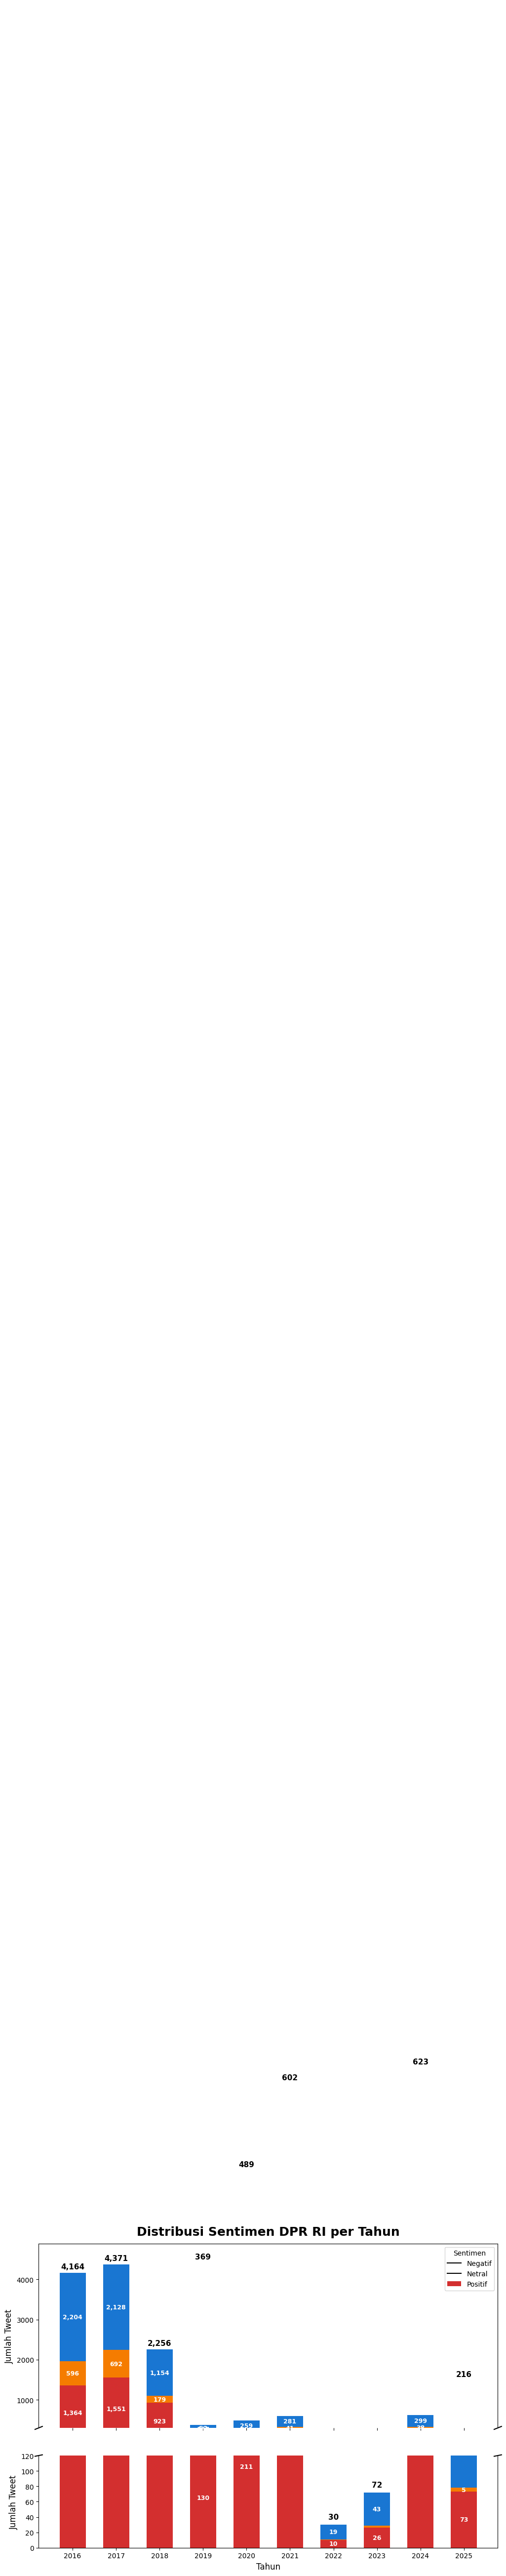

Grafik disimpan di: ../outputs/sentimen_stacked_broken_axis.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

INPUT_PATH = '../outputs/sentiment_clean.csv'
OUTPUT_DIR = '../outputs/'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Membaca data
df = pd.read_csv(INPUT_PATH)

# Ambil tahun dari timestamp
df['year'] = pd.to_datetime(df['timestamp']).dt.year

# Hitung jumlah sentimen per tahun
sentiment_year = pd.crosstab(
    df['year'],
    df['sentiment']
)

# Mengatur urutan kolom
sentiment_year = sentiment_year.reindex(
    columns=['negative', 'neutral', 'positive'],
    fill_value=0
)

# Warna
colors = ['#d32f2f', '#f57c00', '#1976d2']

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

sentiment_year.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=ax
)

ax.set_title(
    'Distribusi Sentimen DPR RI per Tahun',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah Tweet')

ax.legend(
    ['Negatif', 'Netral', 'Positif'],
    title='Sentimen'
)

plt.tight_layout()

output_path = os.path.join(
    OUTPUT_DIR,
    'sentimen_stacked_per_tahun.png'
)

plt.savefig(output_path, dpi=300)
plt.show()

print(f"Grafik berhasil disimpan di: {output_path}")